### [Fancy Heatmaps Using Seaborn](https://medium.com/top-python-libraries/9-fancy-heatmaps-we-plotted-using-seaborn-52888385801c)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

import warnings
warnings.filterwarnings('ignore')

#### **Ratio Heatmap**

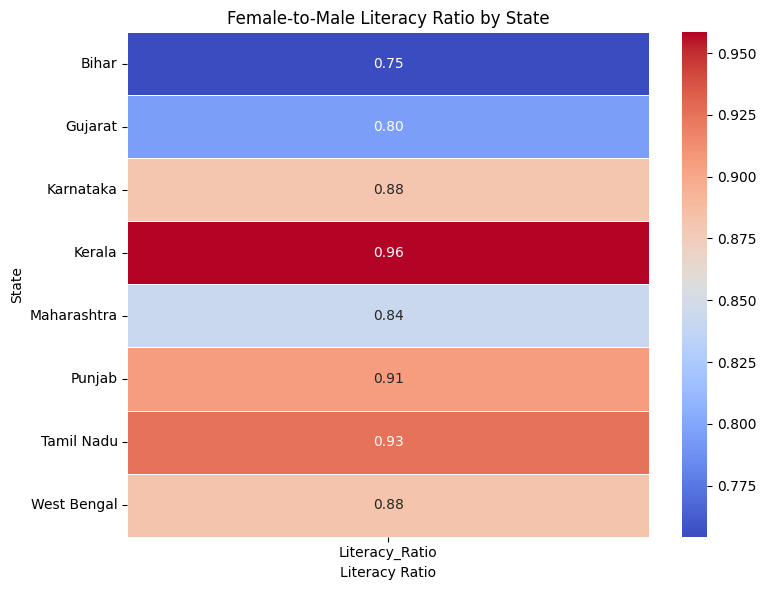

In [2]:
data = {
    'State': ['Maharashtra', 'Kerala', 'Bihar', 'Tamil Nadu', 'Gujarat', 'Punjab', 'West Bengal', 'Karnataka'],
    'Male_Literacy': [89.5, 96.1, 79.8, 91.0, 88.4, 89.9, 87.2, 88.7],
    'Female_Literacy': [75.4, 92.1, 60.2, 84.2, 70.3, 81.4, 76.9, 78.1]
}

df = pd.DataFrame(data)
df['Literacy_Ratio'] = df['Female_Literacy'] / df['Male_Literacy']

heatmap_data = df.pivot_table(index='State', values='Literacy_Ratio')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Female-to-Male Literacy Ratio by State')
plt.xlabel('Literacy Ratio')
plt.ylabel('State')
plt.tight_layout()
plt.show()

#### **Hourly Heatmap**

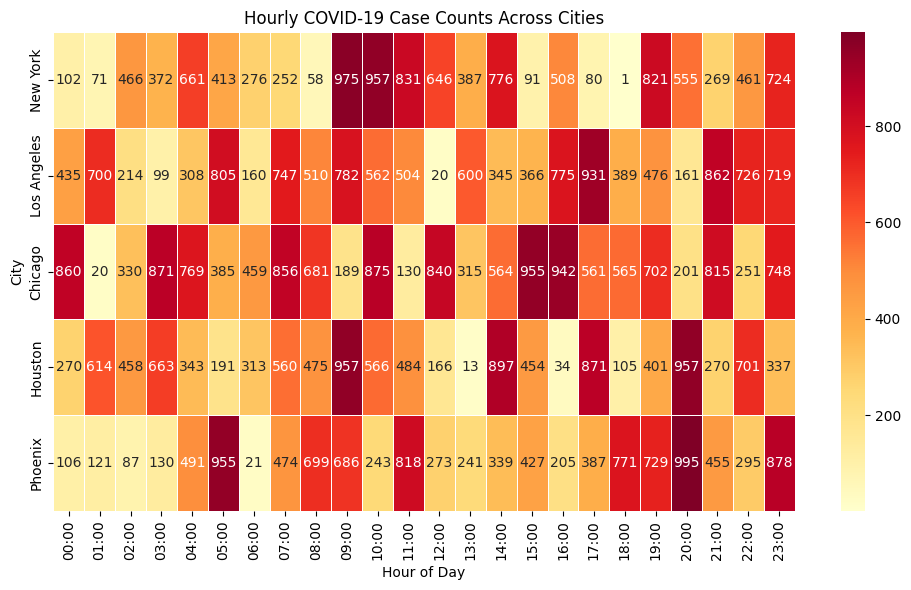

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dummy DataFrame to simulate covid_hourly_cases.csv
hours = [f'{h:02d}:00' for h in range(24)]
cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']

np.random.seed(42)
data = np.random.randint(0, 1000, size=(len(hours), len(cities)))
df = pd.DataFrame(data, index=hours, columns=cities)
df.index.name = 'Hour'

plt.figure(figsize=(10, 6))
sns.heatmap(df.T, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('Hourly COVID-19 Case Counts Across Cities')
plt.xlabel('Hour of Day')
plt.ylabel('City')
plt.tight_layout()
plt.show()

#### **Weighted Average Heatmap**

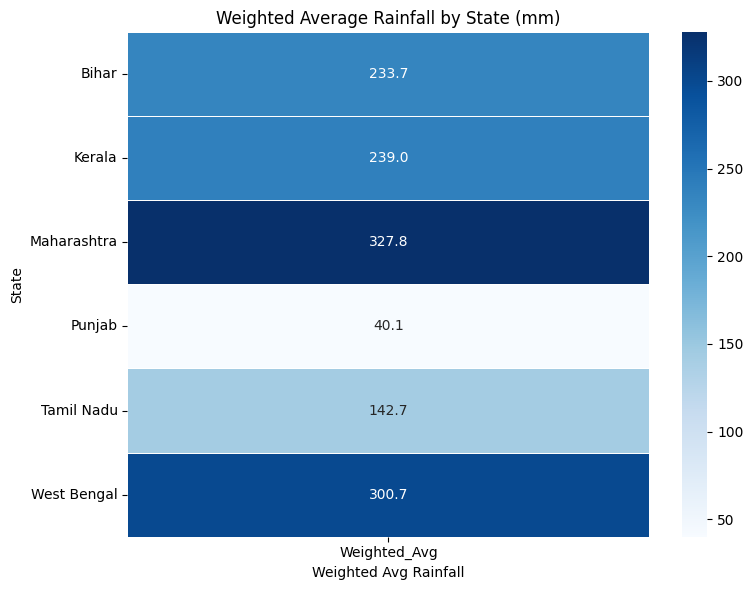

In [4]:
data = {
    'State': ['Kerala', 'Maharashtra', 'Bihar', 'Punjab', 'Tamil Nadu', 'West Bengal'],
    'Avg_Rainfall': [3100, 1200, 1020, 650, 900, 1500],
    'Population': [35, 124, 104, 28, 72, 91]  # in millions
}

df = pd.DataFrame(data)

df['Weighted_Rainfall'] = df['Avg_Rainfall'] * df['Population']

total_population = df['Population'].sum()
df['Weighted_Avg'] = df['Weighted_Rainfall'] / total_population

heatmap_data = df.pivot_table(index='State', values='Weighted_Avg')

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='Blues', fmt=".1f", linewidths=0.5)
plt.title('Weighted Average Rainfall by State (mm)')
plt.xlabel('Weighted Avg Rainfall')
plt.ylabel('State')
plt.tight_layout()
plt.show()

#### **Masked Upper-Triangle Heatmap**

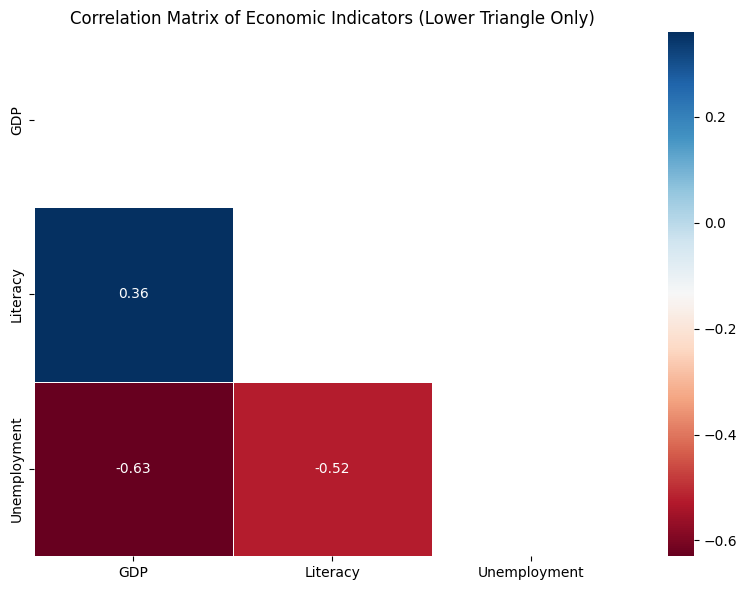

In [5]:
data = {
    'State': ['Kerala', 'Maharashtra', 'Bihar', 'Punjab', 'Tamil Nadu', 'West Bengal'],
    'GDP': [8.5, 25.3, 4.2, 6.7, 12.1, 10.4],  # in lakh crore INR
    'Literacy': [94.0, 82.3, 61.8, 76.7, 80.1, 77.1],  # %
    'Unemployment': [6.2, 4.8, 7.9, 5.5, 4.2, 6.1]  # %
}

df = pd.DataFrame(data)
df.set_index('State', inplace=True)

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Economic Indicators (Lower Triangle Only)')
plt.tight_layout()
plt.show()

#### **Time-Series Heatmap**

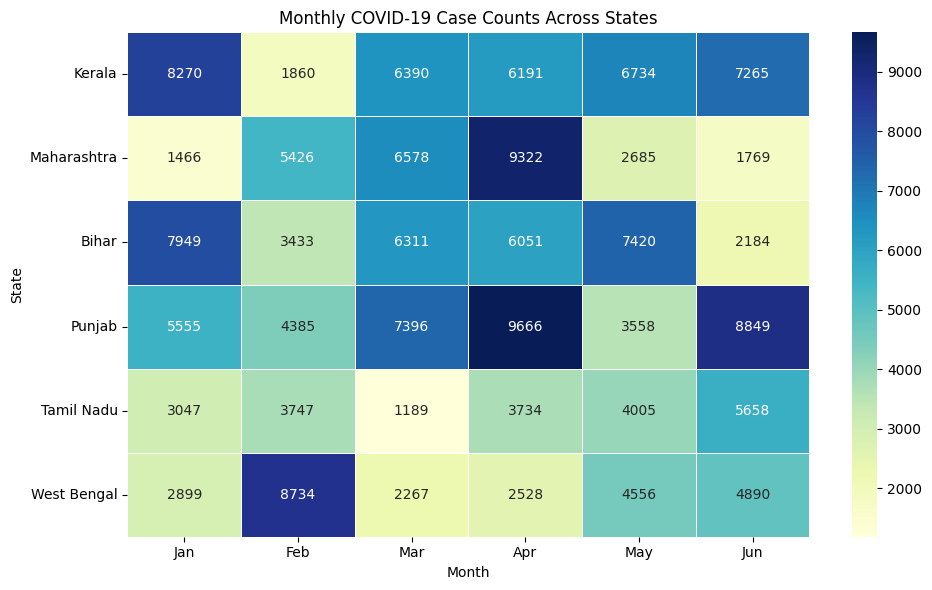

In [6]:
states = ['Kerala', 'Maharashtra', 'Bihar', 'Punjab', 'Tamil Nadu', 'West Bengal']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

np.random.seed(42)
data = {state: np.random.randint(1000, 10000, size=6) for state in states}
df = pd.DataFrame(data, index=months)

# Plotting
plt.figure(figsize=(10, 6))
sns.heatmap(df.T, cmap='YlGnBu', annot=True, fmt='d', linewidths=0.5)
plt.title('Monthly COVID-19 Case Counts Across States')
plt.xlabel('Month')
plt.ylabel('State')
plt.tight_layout()
plt.show()

#### **Temperature Variation Heatmap**

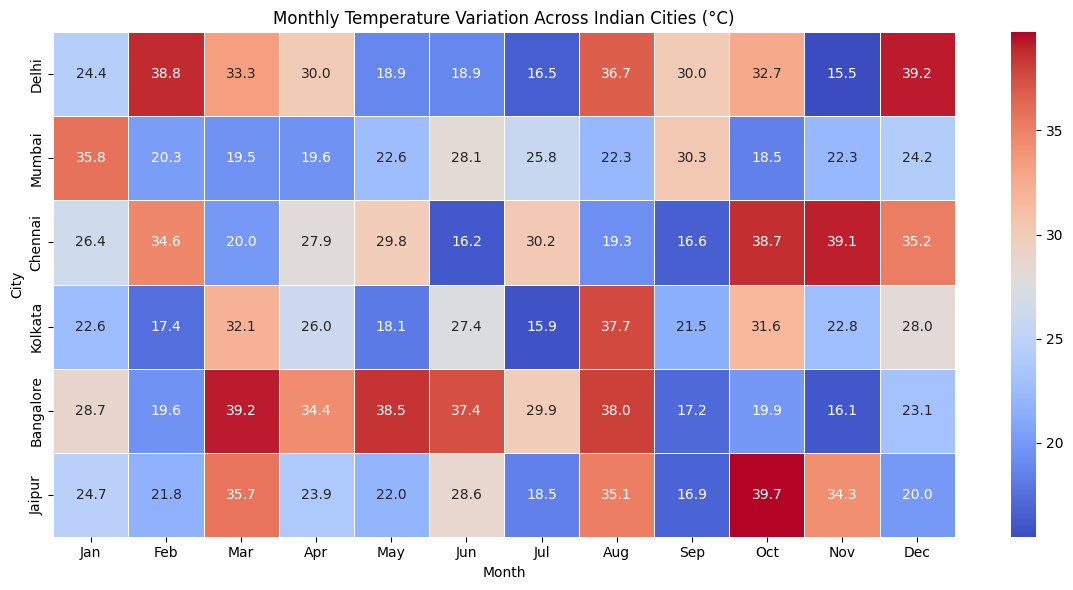

In [7]:
cities = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore', 'Jaipur']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

np.random.seed(42)
data = {city: np.random.uniform(15, 40, size=12).round(1) for city in cities}
df = pd.DataFrame(data, index=months)

# Plotting
plt.figure(figsize=(12, 6))
sns.heatmap(df.T, cmap='coolwarm', annot=True, fmt=".1f", linewidths=0.5)
plt.title('Monthly Temperature Variation Across Indian Cities (°C)')
plt.xlabel('Month')
plt.ylabel('City')
plt.tight_layout()
plt.show()

#### **Skewness Heatmap**

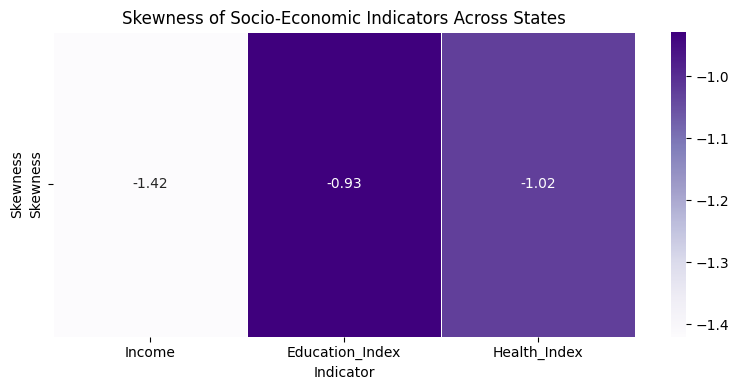

In [8]:
from scipy.stats import skew

data = {
    'State': ['Kerala', 'Maharashtra', 'Bihar', 'Punjab', 'Tamil Nadu', 'West Bengal'],
    'Income': [45000, 52000, 30000, 48000, 50000, 47000],
    'Education_Index': [0.85, 0.78, 0.60, 0.75, 0.80, 0.74],
    'Health_Index': [0.82, 0.76, 0.58, 0.73, 0.79, 0.72]
}

df = pd.DataFrame(data)
df.set_index('State', inplace=True)

skewness_values = df.apply(skew, axis=0).to_frame(name='Skewness').T

# Plotting
plt.figure(figsize=(8, 4))
sns.heatmap(skewness_values, annot=True, cmap='Purples', fmt=".2f", linewidths=0.5)
plt.title('Skewness of Socio-Economic Indicators Across States')
plt.xlabel('Indicator')
plt.ylabel('Skewness')
plt.tight_layout()
plt.show()

#### **Kurtosis Heatmap**

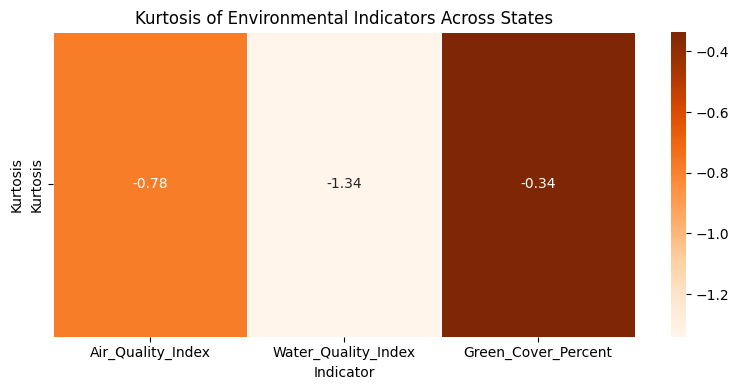

In [9]:
from scipy.stats import kurtosis

data = {
    'State': ['California', 'Texas', 'Florida', 'New York', 'Illinois', 'Ohio'],
    'Air_Quality_Index': [42, 55, 48, 60, 50, 53],
    'Water_Quality_Index': [78, 65, 70, 80, 72, 68],
    'Green_Cover_Percent': [33, 25, 29, 40, 31, 28]
}

df = pd.DataFrame(data)
df.set_index('State', inplace=True)

kurtosis_values = df.apply(kurtosis, axis=0).to_frame(name='Kurtosis').T

# Plotting
plt.figure(figsize=(8, 4))
sns.heatmap(kurtosis_values, annot=True, cmap='Oranges', fmt=".2f", linewidths=0.5)
plt.title('Kurtosis of Environmental Indicators Across States')
plt.xlabel('Indicator')
plt.ylabel('Kurtosis')
plt.tight_layout()
plt.show()

#### **Polar Heatmap**

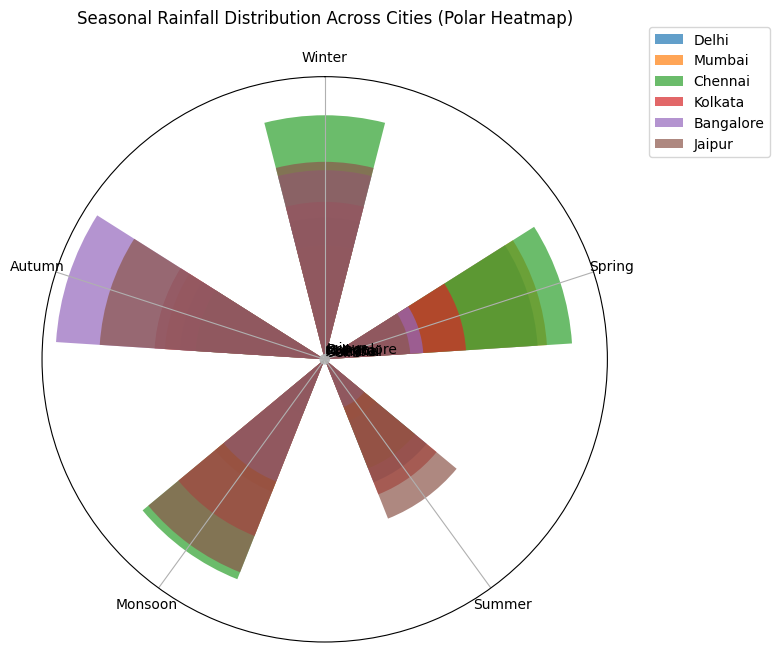

In [10]:
cities = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore', 'Jaipur']
seasons = ['Winter', 'Spring', 'Summer', 'Monsoon', 'Autumn']

np.random.seed(42)
rainfall_data = np.random.randint(50, 300, size=(len(cities), len(seasons)))
df = pd.DataFrame(rainfall_data, index=cities, columns=seasons)

theta = np.linspace(0, 2 * np.pi, len(seasons), endpoint=False)
r = np.arange(len(cities))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, city in enumerate(cities):
    values = df.iloc[i].values
    bars = ax.bar(theta, values, width=0.5, bottom=i, label=city, alpha=0.7)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(theta)
ax.set_xticklabels(seasons)
ax.set_yticks(r)
ax.set_yticklabels(cities)
plt.title('Seasonal Rainfall Distribution Across Cities (Polar Heatmap)', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()